<a href="https://colab.research.google.com/github/di5han/AIFinalAssessment/blob/main/2461998_DishanKumarAdhikari_ClassificationCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sns.set(style="whitegrid")

In [97]:
df = pd.read_csv("/content/drive/MyDrive/AIAssignment/Healthcare Risk Factors Dataset.csv")

df.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426


In [98]:
features = [
    "Age",
    "BMI",
    "Stress Level",
    "Physical Activity",
    "Sleep Hours"
]

target = "Smoking"

data = df[features + [target]]

In [99]:
le = LabelEncoder()
data[target] = le.fit_transform(data[target])

/tmp/ipython-input-3704639300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[target] = le.fit_transform(data[target])


In [100]:
data.isnull().sum()

,0
Age,4500
BMI,0
Stress Level,0
Physical Activity,0
Sleep Hours,0
Smoking,0


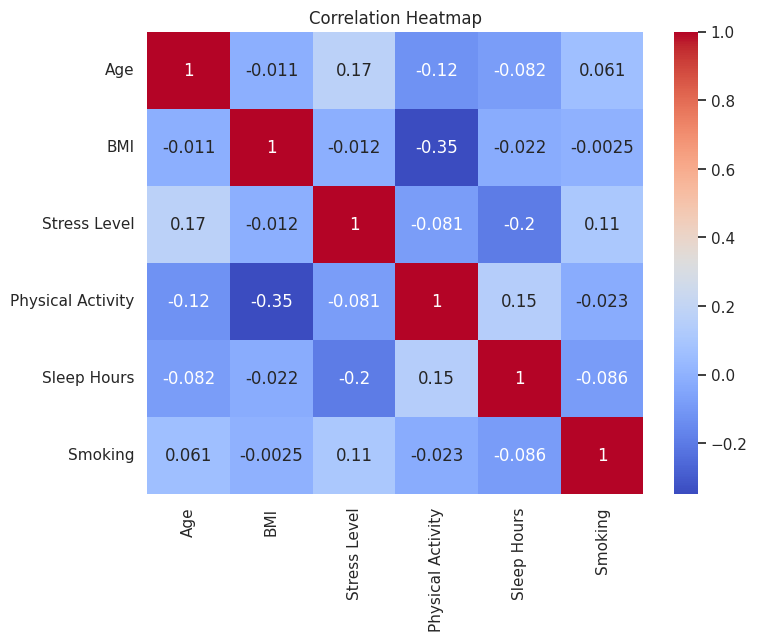

In [101]:
plt.figure(figsize=(8,6))
numeric_data = data.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [102]:
X = data[features].select_dtypes(include=["int64", "float64"])
y = data[target]

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [104]:
imputer = SimpleImputer(strategy="mean")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [105]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [106]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1:", f1_score(y_test, pred_lr))

Logistic Regression
Accuracy: 0.7166666666666667
Precision: 1.0
Recall: 0.0005878894767783657
F1: 0.0011750881316098707


In [107]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1:", f1_score(y_test, pred_rf))

Random Forest
Accuracy: 0.7046666666666667
Precision: 0.34763948497854075
Recall: 0.047619047619047616
F1: 0.08376421923474664


In [108]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_

({'max_depth': 10, 'n_estimators': 100}, np.float64(0.7204583333333333))

In [109]:
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=3)
rfe.fit(X_train_scaled, y_train)

selected_features = np.array(X.columns)[rfe.support_]
selected_features

array(['Age', 'Stress Level', 'Sleep Hours'], dtype=object)

In [110]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="relu",
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

pred_mlp = mlp.predict(X_test_scaled)

print("Neural Network")
print("Accuracy:", accuracy_score(y_test, pred_mlp))
print("F1:", f1_score(y_test, pred_mlp))

Neural Network
Accuracy: 0.7051666666666667
F1: 0.07139107611548556


In [111]:
final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_mlp)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_mlp)
    ]
})

final_results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.716667,0.001175
1,Random Forest,0.704667,0.083764
2,Neural Network,0.705167,0.071391
